   Month  Rainfall (mm)
0    Jan       5.629758
1    Feb      30.740278
2    Mar      28.458468
3    Apr      63.707512
4    May     167.821340
5    Jun     229.828616
6    Jul     481.887785
7    Aug     299.426934
8    Sep     315.254689
9    Oct     221.674381
10   Nov       5.976962
11   Dec       0.464975


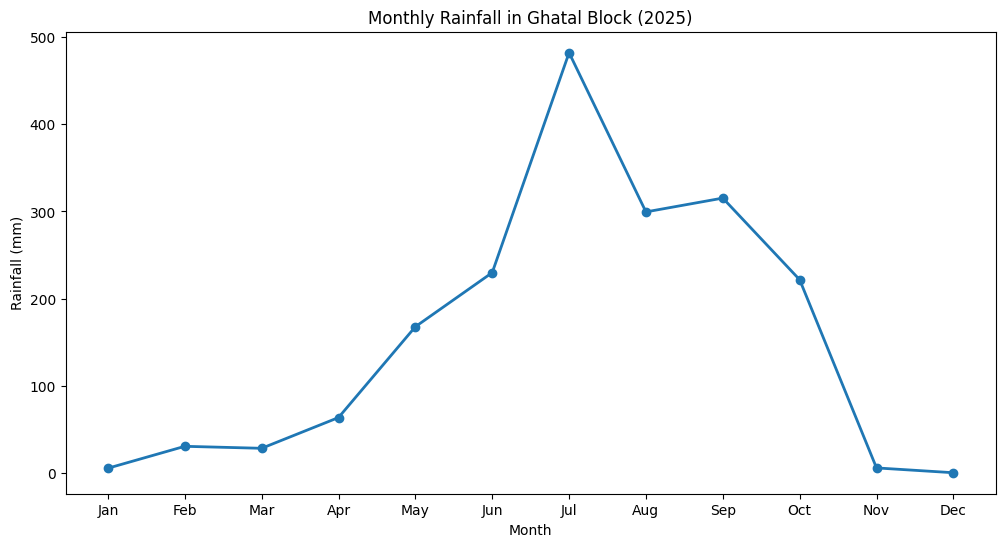

In [ ]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Initialize Earth Engine
ee.Initialize(project='ee-debrajkolya')

# Load Shapefile
shp_path = r"D:\Google Earth Engine\GEE_MAP_Python\ee-debrajkolya\Flood & Soil moisture project\Shapefile\Ghatal.shp"

gdf = gpd.read_file(shp_path)

aoi = geemap.geopandas_to_ee(gdf)

# Year for analysis
year = 2025

# Monthly Rainfall Calculation (CHIRPS)
monthly_rainfall = []

for month in range(1, 13):

    start_date = f'{year}-{month:02d}-01'

    # End date
    if month == 12:
        end_date = f'{year+1}-01-01'
    else:
        end_date = f'{year}-{month+1:02d}-01'

    # CHIRPS Daily Rainfall
    rainfall = (
        ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
        .filterDate(start_date, end_date)
        .select('precipitation')
        .sum()
    )

    # Mean rainfall over Ghatal Block
    stats = rainfall.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi.geometry(),
        scale=5500,
        maxPixels=1e13
    )

    rain_value = stats.get('precipitation').getInfo()

    monthly_rainfall.append(rain_value)

# Create DataFrame
months = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

df = pd.DataFrame({
    'Month': months,
    'Rainfall (mm)': monthly_rainfall
})

print(df)

# Plot Rainfall Graph
plt.figure(figsize=(12, 6))

plt.plot(
    df['Month'],
    df['Rainfall (mm)'],
    marker='o',
    linewidth=2
)

plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.title('Monthly Rainfall in Ghatal Block (2025)')
# plt.grid(True)

plt.show()